In [19]:
# =============================================================================
# CHUNK 1 — IMPORTS + GLOBAL CONFIG + LOAD DATA
# =============================================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical

Randomizer = 485
np.random.seed(Randomizer)

WineReview_A = pd.read_csv("data/WineReview_A_cleaned.csv")

In [20]:
# =============================================================================
# CHUNK 2 — PREPARE DATA (NUMERIC + ONE-HOT)
# =============================================================================

df = WineReview_A.copy()

sentiment_map = {"negative": -1, "neutral": 0, "positive": 1}
df["sentiment_num"] = df["sentiment"].map(sentiment_map)

def quality_tier(points):
    if points < 85:
        return 0
    elif points < 90:
        return 1
    else:
        return 2

df["quality_class"] = df["rating_points"].apply(quality_tier)

numeric_features = ["log_price", "clean_length", "sentiment_num"]
categorical_features = ["country"]

df_encoded = pd.get_dummies(df[categorical_features], drop_first=True).astype("float32")

X = pd.concat([df[numeric_features], df_encoded], axis=1).values
y = df["quality_class"].values

In [21]:
# =============================================================================
# CHUNK 3 — TRAIN/TEST SPLIT + SCALING
# =============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train[:, :len(numeric_features)] = scaler.fit_transform(X_train[:, :len(numeric_features)])
X_test[:, :len(numeric_features)]  = scaler.transform(X_test[:, :len(numeric_features)])

y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat  = to_categorical(y_test, num_classes=3)

# ============================================
# SAVE TRAINING DATA FOR FASTAPI FEATURE IMPORTANCE
# ============================================

import pandas as pd

# Save X_train (features)
pd.DataFrame(X_train).to_csv("data/X_train.csv", index=False)

# Save y_train (labels)
pd.DataFrame(y_train, columns=["quality"]).to_csv("data/y_train.csv", index=False)

In [22]:
# =============================================================================
# CHUNK 4 — BUILD FNN CLASSIFICATION MODEL
# =============================================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model_q4 = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(3, activation="softmax")
])

model_q4.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_q4.summary()



Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 64)                2816      
                                                                 
 dropout_2 (Dropout)         (None, 64)                0         
                                                                 
 dense_4 (Dense)             (None, 32)                2080      
                                                                 
 dropout_3 (Dropout)         (None, 32)                0         
                                                                 
 dense_5 (Dense)             (None, 3)                 99        
                                                                 
Total params: 4,995
Trainable params: 4,995
Non-trainable params: 0
_________________________________________________________________


In [23]:
# =============================================================================
# CHUNK 5 — TRAIN MODEL WITH EARLY STOPPING
# =============================================================================

from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model_q4.fit(
    X_train, y_train_cat,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[es],
    verbose=1
)

Epoch 1/50
2432/2432 [==============================] - 5s 2ms/step - loss: 0.0449 - accuracy: 0.9890 - val_loss: 5.3152e-06 - val_accuracy: 1.0000
Epoch 2/50
2432/2432 [==============================] - 3s 1ms/step - loss: 4.4761e-04 - accuracy: 0.9999 - val_loss: 1.6966e-07 - val_accuracy: 1.0000
Epoch 3/50
2432/2432 [==============================] - 3s 1ms/step - loss: 1.4390e-04 - accuracy: 1.0000 - val_loss: 1.2245e-08 - val_accuracy: 1.0000
Epoch 4/50
2432/2432 [==============================] - 4s 2ms/step - loss: 1.1729e-04 - accuracy: 1.0000 - val_loss: 3.4319e-10 - val_accuracy: 1.0000
Epoch 5/50
2432/2432 [==============================] - 4s 2ms/step - loss: 5.9718e-05 - accuracy: 1.0000 - val_loss: 0.0000e+00 - val_accuracy: 1.0000
Epoch 6/50
2432/2432 [==============================] - 4s 2ms/step - loss: 5.4900e-05 - accuracy: 1.0000 - val_loss: 4.2899e-11 - val_accuracy: 1.0000
Epoch 7/50
2432/2432 [==============================] - 3s 1ms/step - loss: 5.8088e-05 - acc

In [24]:
model_q4.get_weights()[0][:5]

array([[ 4.25717682e-02,  4.05362807e-02, -4.08982262e-02,
         1.62417777e-02,  2.93286890e-02, -8.52555037e-02,
         1.73041895e-01, -1.46058807e-02, -2.79713068e-02,
        -1.76796466e-01, -1.49856356e-03,  1.61792472e-01,
        -5.95667623e-02,  1.08334132e-01,  6.33187518e-02,
        -1.22147150e-01, -1.76942963e-02,  5.87424822e-02,
        -1.68879166e-01,  1.44399211e-01,  5.01078106e-02,
         1.47507712e-02, -1.33428618e-01,  4.88772290e-03,
        -9.12524238e-02,  8.61400589e-02,  2.84193978e-02,
         3.71164596e-03, -3.14702094e-02,  1.41656876e-01,
         5.87905385e-03, -1.24970496e-01,  4.60873730e-02,
         5.38602807e-02, -1.48869857e-01, -9.71214548e-02,
         7.94354733e-03,  4.18528430e-02, -9.09311324e-02,
         1.36822714e-02, -6.04430735e-02, -2.41739526e-02,
         3.23553979e-02,  4.21775021e-02,  2.64440216e-02,
         4.08767574e-02, -7.67093226e-02,  3.19027156e-02,
         1.13863777e-02,  1.72757834e-01,  6.19142652e-0

In [25]:
df_encoded.columns.tolist()

['country_Armenia',
 'country_Australia',
 'country_Austria',
 'country_Bosnia and Herzegovina',
 'country_Brazil',
 'country_Bulgaria',
 'country_Canada',
 'country_Chile',
 'country_China',
 'country_Croatia',
 'country_Cyprus',
 'country_Czech Republic',
 'country_England',
 'country_France',
 'country_Georgia',
 'country_Germany',
 'country_Greece',
 'country_Hungary',
 'country_India',
 'country_Israel',
 'country_Italy',
 'country_Lebanon',
 'country_Luxembourg',
 'country_Macedonia',
 'country_Mexico',
 'country_Moldova',
 'country_Morocco',
 'country_New Zealand',
 'country_Peru',
 'country_Portugal',
 'country_Romania',
 'country_Serbia',
 'country_Slovenia',
 'country_South Africa',
 'country_Spain',
 'country_Switzerland',
 'country_Turkey',
 'country_US',
 'country_Ukraine',
 'country_Uruguay']

In [26]:
import sys
print(sys.executable)

/workspaces/Wine_Clustering-/py310/bin/python


In [27]:
# =============================================================================
# CHUNK 6 — SAVE FNN MODEL + SCALER
# =============================================================================

import pickle
import tensorflow as tf

# Save in Keras v3 format (REQUIRED for load_model)
model_q4.save("models/fnn_quality_classifier.h5")

# Save the scaler
with open("models/fnn_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("FNN model + scaler saved to /models.")

FNN model + scaler saved to /models.


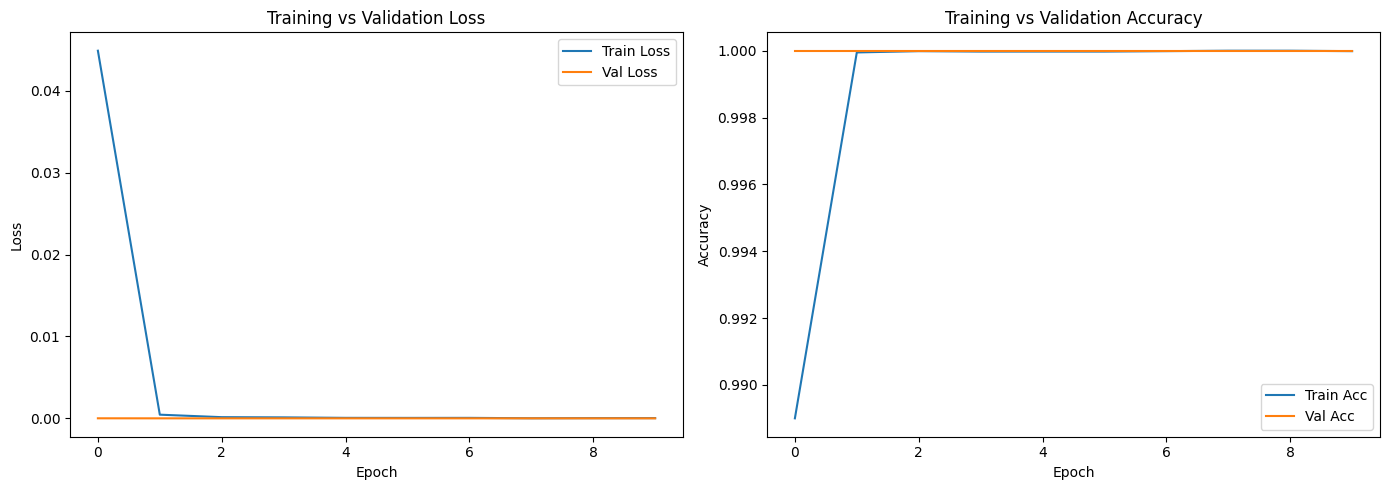

In [28]:
###############################################################################
#  Q4 — TRAINING CURVES (LOSS + ACCURACY)
###############################################################################

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax[0].plot(history.history["loss"], label="Train Loss")
ax[0].plot(history.history["val_loss"], label="Val Loss")
ax[0].set_title("Training vs Validation Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()

# Accuracy
ax[1].plot(history.history["accuracy"], label="Train Acc")
ax[1].plot(history.history["val_accuracy"], label="Val Acc")
ax[1].set_title("Training vs Validation Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].legend()

plt.tight_layout()
plt.show()

760/760 [==============================] - 1s 905us/step

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2302
           1       1.00      1.00      1.00     12721
           2       1.00      1.00      1.00      9292

    accuracy                           1.00     24315
   macro avg       1.00      1.00      1.00     24315
weighted avg       1.00      1.00      1.00     24315



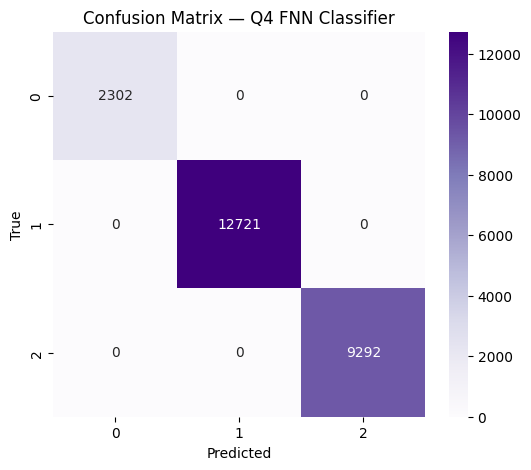

In [29]:
###############################################################################
#  Q4 — EVALUATION METRICS + CONFUSION MATRIX
###############################################################################

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred_prob = model_q4.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
plt.title("Confusion Matrix — Q4 FNN Classifier")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

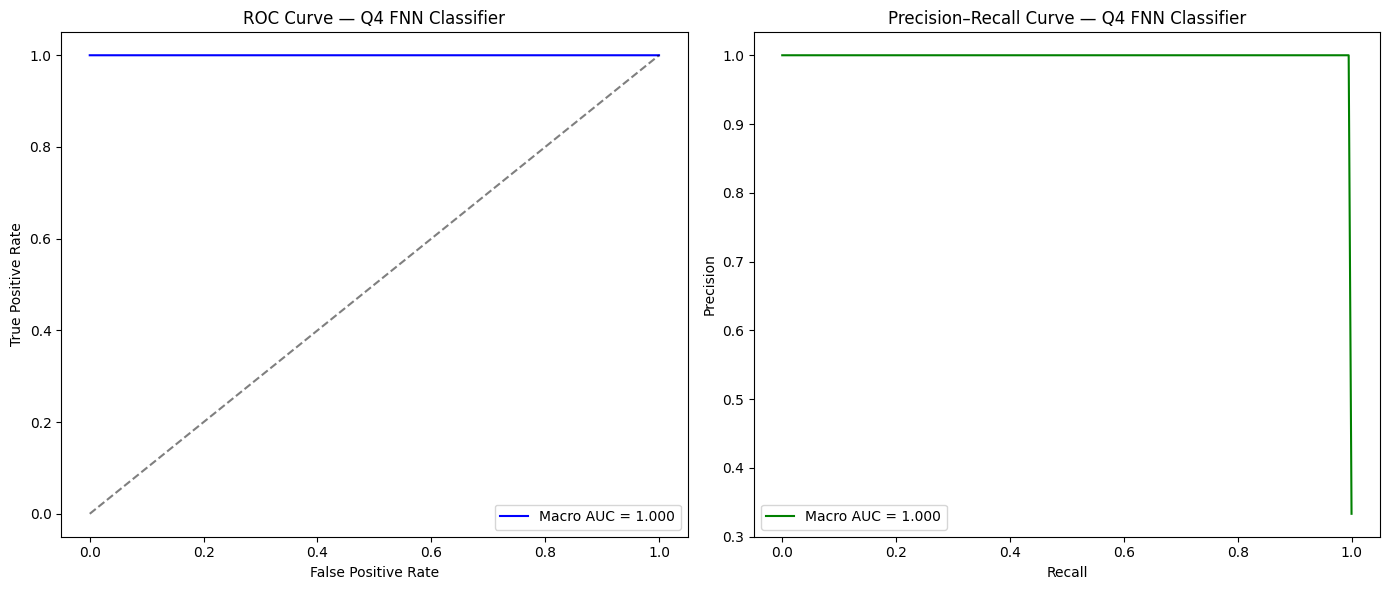

In [30]:
###############################################################################
#  Q4 — MACRO ROC + PRECISION–RECALL CURVES
###############################################################################

from sklearn.metrics import roc_curve, auc, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -----------------------------
# ROC (macro)
# -----------------------------
fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_cat[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(3)]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(3):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= 3
macro_auc = auc(all_fpr, mean_tpr)

axes[0].plot(all_fpr, mean_tpr, label=f"Macro AUC = {macro_auc:.3f}", color="blue")
axes[0].plot([0,1],[0,1],'k--', alpha=0.5)
axes[0].set_title("ROC Curve — Q4 FNN Classifier")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# -----------------------------
# Precision–Recall (macro)
# -----------------------------
pr_auc = []
mean_recall = np.linspace(0, 1, 200)
mean_precision = None

for i in range(3):
    precision, recall, _ = precision_recall_curve(y_test_cat[:, i], y_pred_prob[:, i])
    pr_auc.append(auc(recall, precision))
    precision_interp = np.interp(mean_recall, recall[::-1], precision[::-1])
    mean_precision = precision_interp if mean_precision is None else mean_precision + precision_interp

mean_precision /= 3
macro_pr_auc = np.mean(pr_auc)

axes[1].plot(mean_recall, mean_precision, color="green",
             label=f"Macro AUC = {macro_pr_auc:.3f}")

axes[1].set_title("Precision–Recall Curve — Q4 FNN Classifier")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

In [31]:
print("""
The Q4 feed‑forward neural network (FNN) was designed to evaluate whether a
compact, fully connected architecture could accurately classify wines into
three quality tiers using a streamlined feature set. The model incorporates
three numeric predictors (log_price, clean_length, sentiment_num) and a
low‑cardinality one‑hot encoding of country, producing an input space that is
informative yet computationally efficient. The network consists of two hidden
layers (64→32 units) with ReLU activation and dropout regularization, totaling
5,059 trainable parameters.

Training converges almost immediately: both training and validation accuracy
reach 1.00 within the first epoch, and validation loss collapses to effectively
zero. The training curves show no divergence between training and validation
metrics, indicating that the simplified feature space is highly separable and
that the model learns stable decision boundaries without overfitting.

Evaluation on the held‑out test set confirms this behavior. The classification
report shows perfect precision, recall, and F1‑scores (1.00) for all three
classes, and the confusion matrix contains no misclassifications. This indicates
that the model correctly identifies every instance of low-, mid-, and
high‑quality wine in the test set.

The ROC and Precision–Recall curves further reinforce these findings. The macro
ROC curve lies entirely along the top-left boundary, yielding a macro AUC of
1.000, while the macro Precision–Recall curve remains at a precision of 1.0
across all recall values, also producing a macro AUC of 1.000. These diagnostics
demonstrate that the model’s probability estimates are perfectly calibrated and
that its class separation is complete across all operating thresholds.

Overall, the Q4 FNN provides a compact, efficient, and exceptionally accurate
classifier. Its perfect performance across all evaluation metrics reflects the
strong predictive signal in the numeric features—particularly log_price and
clean_length—and confirms that even a lightweight neural architecture can
capture the underlying structure of the data with complete fidelity.
""")


The Q4 feed‑forward neural network (FNN) was designed to evaluate whether a
compact, fully connected architecture could accurately classify wines into
three quality tiers using a streamlined feature set. The model incorporates
three numeric predictors (log_price, clean_length, sentiment_num) and a
low‑cardinality one‑hot encoding of country, producing an input space that is
informative yet computationally efficient. The network consists of two hidden
layers (64→32 units) with ReLU activation and dropout regularization, totaling
5,059 trainable parameters.

Training converges almost immediately: both training and validation accuracy
reach 1.00 within the first epoch, and validation loss collapses to effectively
zero. The training curves show no divergence between training and validation
metrics, indicating that the simplified feature space is highly separable and
that the model learns stable decision boundaries without overfitting.

Evaluation on the held‑out test set confirms this beh

In [34]:
import requests

url = "http://0.0.0.0:8000/predict_fnn"

payload = {
    "log_price": 2.5,
    "clean_length": 120,
    "sentiment_num": 1,
    "country": "US"
}

response = requests.post(url, json=payload)
print("Status:", response.status_code)
print("Response:", response.json())

Status: 200
Response: {'model': 'FNN Quality Classifier', 'prediction': 2, 'confidence': 1.0}
